In [ ]:
#!pip install --upgrade --force-reinstall tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 

In [ ]:
!pip install opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 3.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import keras
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications import ResNet50, InceptionResNetV2
from keras.layers import GlobalAveragePooling2D
import warnings
warnings.filterwarnings(action="ignore")


import matplotlib.pyplot as plt
%matplotlib inline
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, MaxPool2D
from keras.losses import CategoricalCrossentropy
from keras.regularizers import l1,l2
from keras import backend as K
from sklearn.linear_model import LinearRegression
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.layers import Input #, Concatenate
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import TensorBoard,EarlyStopping
from sklearn.preprocessing import LabelEncoder
import sklearn.metrics as metrics
from keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x, verbose=0)
input_shape = (224,224,3)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Function to perform augmentation on an image
def augment_image(image):
    # Example augmentations: flip horizontally, flip vertically, and rotate by 45 degrees
    augmented_images = [
        cv2.flip(image, 1),  # Horizontal flip
        cv2.flip(image, 0),  # Vertical flip
        cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE),
        cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE),
        cv2.rotate(image, cv2.ROTATE_180),
    ]
    return augmented_images

# Function to augment and save images
def augmentation(original_dir, aug_dir):
    # Loop through each image in the original directory
    for filename in os.listdir(original_dir):
        if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.JPEG'):
            img = cv2.imread(os.path.join(original_dir, filename))
            augmented_images = augment_image(img)
            # Save augmented images back to the same directory
            for idx, augmented_img in enumerate(augmented_images):
                new_filename = os.path.splitext(filename)[0] + '_augmented_' + str(idx) + os.path.splitext(filename)[1]
                cv2.imwrite(os.path.join(aug_dir, new_filename), augmented_img)
    print("Augmentation complete.")


In [ ]:
original_dirs = [
    r'/content/drive/MyDrive/Osteo/dataset/dataset1/normal',
    r'/content/drive/MyDrive/Osteo/dataset/dataset2/normal',
    r'/content/drive/MyDrive/Osteo/dataset/dataset3/normal'
]
aug_dir = '/content/drive/MyDrive/Osteo/Working/normal'
if not os.path.exists(aug_dir):
    os.makedirs(aug_dir)
for original_dir in original_dirs:
    augmentation(original_dir, aug_dir)

original_dirs = [
    r'/content/drive/MyDrive/Osteo/dataset/dataset1/osteoporosis',
    r'/content/drive/MyDrive/Osteo/dataset/dataset2/osteoporosis',
    r'/content/drive/MyDrive/Osteo/dataset/dataset3/osteoporosis'
]
aug_dir = '/content/drive/MyDrive/Osteo/Working/osteo'
if not os.path.exists(aug_dir):
    os.makedirs(aug_dir)
for original_dir in original_dirs:
    augmentation(original_dir, aug_dir)


Augmentation complete.
Augmentation complete.
Augmentation complete.
Augmentation complete.
Augmentation complete.
Augmentation complete.


In [ ]:
healthy_dirs = [
    r'/content/drive/MyDrive/Osteo/Working/normal'
]
osteoporosis_dirs = [
    r'/content/drive/MyDrive/Osteo/Working/osteo'
]
filepaths = []
labels = []
dict_lists = [healthy_dirs, osteoporosis_dirs]
class_labels = ['Healthy', 'Osteoporosis']

for i, dir_list in enumerate(dict_lists):
    for j in dir_list:
        flist = os.listdir(j)
        for f in flist:
            fpath = os.path.join(j, f)
            filepaths.append(fpath)
            labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
knee_osteoporosis_data = pd.concat([Fseries, Lseries], axis=1)
knee_osteoporosis_df = pd.DataFrame(knee_osteoporosis_data)
print(knee_osteoporosis_df.head())
print(knee_osteoporosis_df["labels"].value_counts())

                                           filepaths   labels
0  /content/drive/MyDrive/Osteo/Working/normal/92...  Healthy
1  /content/drive/MyDrive/Osteo/Working/normal/10...  Healthy
2  /content/drive/MyDrive/Osteo/Working/normal/10...  Healthy
3  /content/drive/MyDrive/Osteo/Working/normal/10...  Healthy
4  /content/drive/MyDrive/Osteo/Working/normal/20...  Healthy
labels
Healthy         1960
Osteoporosis    1893
Name: count, dtype: int64


In [ ]:
knee_osteoporosis_df.shape

(3853, 2)

In [ ]:
train_images, test_images = train_test_split(knee_osteoporosis_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(knee_osteoporosis_df, test_size=0.2, random_state=42)

In [ ]:
target_size = (224, 224)
batch_size = 8

image_gen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train = image_gen.flow_from_dataframe(
    dataframe=train_images,
    x_col="filepaths",
    y_col="labels",
    target_size=target_size,
    color_mode='rgb',
    class_mode="categorical",  # used for Sequential Model
    batch_size=batch_size,
    shuffle=False  # do not shuffle data
)

test = image_gen.flow_from_dataframe(
    dataframe=test_images,
    x_col="filepaths",
    y_col="labels",
    target_size=target_size,
    color_mode='rgb',
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False
)

val = image_gen.flow_from_dataframe(
    dataframe=val_set,
    x_col="filepaths",
    y_col="labels",
    target_size=target_size,
    color_mode='rgb',
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False
)

Found 2697 validated image filenames belonging to 2 classes.
Found 1156 validated image filenames belonging to 2 classes.
Found 771 validated image filenames belonging to 2 classes.


In [ ]:
# Function to show images from a generator
def show_knee_images(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels = next(image_gen)  # get a sample batch from the generator
    plt.figure(figsize=(20, 20))
    length = len(labels)
    if length < 25:
        r = length
    else:
        r = 25
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image = (images[i] + 1) / 2  # scale images between 0 and 1
        plt.imshow(image)
        index = np.argmax(labels[i])
        class_name = classes[index]
        plt.title(class_name, color="green", fontsize=16)
        plt.axis('off')
    plt.show()

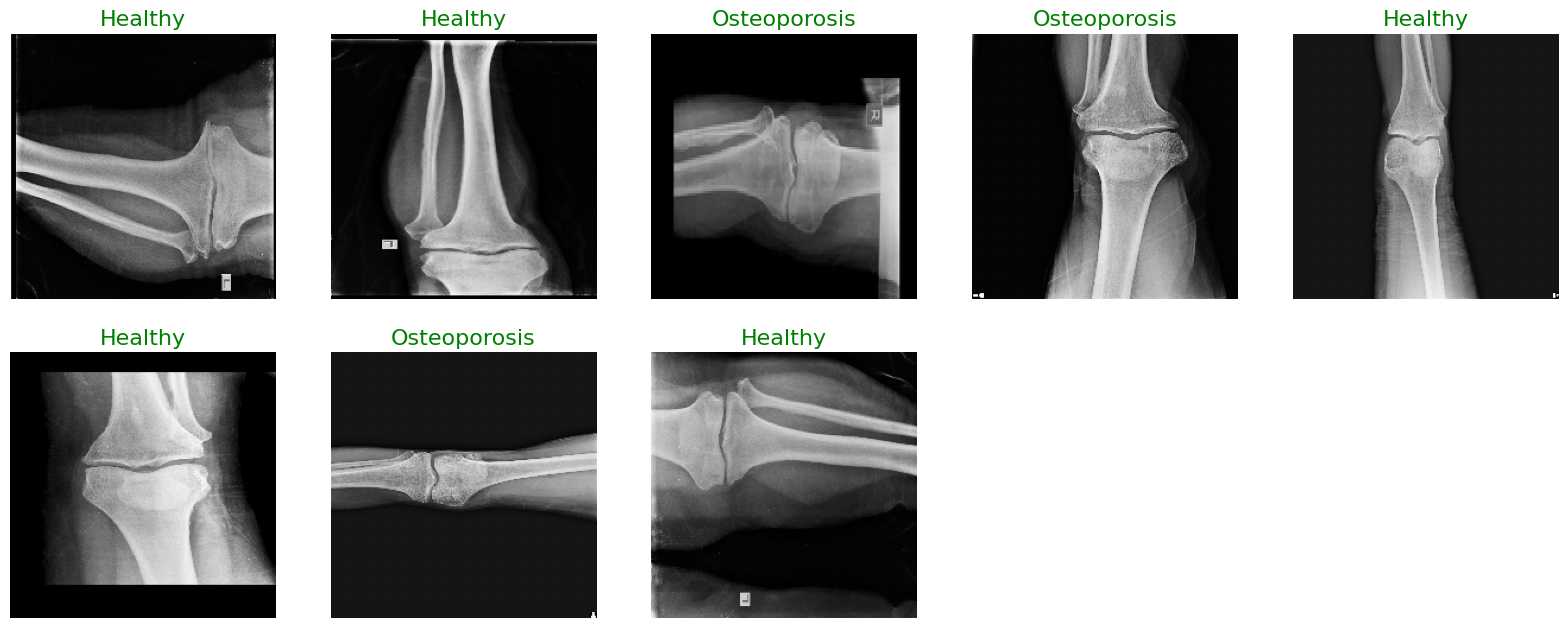

In [ ]:
show_knee_images(train)

In [ ]:
# Function to create a CNN model
def create_cnn_model(filters, dropout_rate, learning_rate=0.0001):
    model = keras.models.Sequential([
        Conv2D(filters=filters, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=(224, 224, 3)),
        BatchNormalization(),
        Conv2D(filters=filters*2, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
        BatchNormalization(),
        MaxPool2D(pool_size=(3, 3)),
        Conv2D(filters=filters*2, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"),
        BatchNormalization(),
        Conv2D(filters=filters*2, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
        BatchNormalization(),
        Conv2D(filters=filters*2, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
        BatchNormalization(),
        MaxPool2D(pool_size=(2, 2)),
        Conv2D(filters=filters*4, kernel_size=(3, 3), activation='relu', padding="same"),
        BatchNormalization(),
        MaxPool2D(pool_size=(2, 2)),
        Conv2D(filters=filters*4, kernel_size=(3, 3), activation='relu', padding="same"),
        BatchNormalization(),
        Conv2D(filters=filters*4, kernel_size=(3, 3), activation='relu', padding="same"),
        BatchNormalization(),
        MaxPool2D(pool_size=(2, 2)),
        Conv2D(filters=filters*4, kernel_size=(3, 3), activation='relu', padding="same"),
        BatchNormalization(),
        MaxPool2D(pool_size=(2, 2)),
        Flatten(),
        Dense(filters*8, activation='relu'),
        Dropout(dropout_rate),
        Dense(filters*8, activation='relu'),
        Dropout(dropout_rate),
        Dense(2, activation='softmax')
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.optimizers.SGD(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    model.summary()
    return model

# Function to draw learning curves
def learning_curve(hist):
    # Create a function to draw learning curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'])
    plt.plot(hist.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'])
    plt.plot(hist.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

# Function to visualize image counts
def visualize_image_counts(root_directory):
    # Initialize dictionaries to store counts
    directory_counts = {}
    # Traverse the root directory
    for dirpath, dirnames, filenames in os.walk(root_directory):
        # Count the number of image files in each directory
        image_files = [f for f in filenames if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        directory_counts[dirpath.split("/")[-1]] = len(image_files)
    # Filter out directories without images
    directory_counts = {k: v for k, v in directory_counts.items() if v > 0}
    # Visualize the counts
    directories = list(directory_counts.keys())
    counts = list(directory_counts.values())
    # Define Seaborn color palette to use
    palette_color = sns.color_palette('bright')
    # Plotting data on chart
    plt.pie(counts, labels=directories, colors=palette_color, autopct='%.0f%%', shadow=True)
    plt.legend(loc='center right', bbox_to_anchor=(1.6, 0.5))
    # Displaying chart
    plt.show()

# Function to fine-tune application model
def keras_app_model(base_model, dropout=0.1, learning_rate=0.0001):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout)(x)
    predictions = Dense(2, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    # Fine-tune optimizer and learning rate
    optimizer = Adam(learning_rate=learning_rate)  # Adjust learning rate as needed
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Function to view classification report
def view_classification_report(model, test, train, test_images):
    pred = model.predict(test)
    pred = np.argmax(pred, axis=1)  # pick class with highest probability
    labels = (train.class_indices)
    labels = dict((v, k) for k, v in labels.items())
    pred2 = [labels[k] for k in pred]
    y_test = test_images.labels  # set y_test to the expected output
    print(classification_report(y_test, pred2))
    print("Accuracy of the Model:", "{:.1f}%".format(accuracy_score(y_test, pred2) * 100))

In [ ]:
filters = 512
dropout_rate = 0.5
learning_rate = 0.0001
cnn_model = create_cnn_model(filters, dropout_rate, learning_rate)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 73, 73, 512)    │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 73, 73, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 73, 73, 1024)   │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 73, 73, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 1024)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 1024)   │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 1024)   │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 1024)   │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 1024)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 2048)   │    18,876,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 2048)   │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 2048)     │    37,750,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 2048)     │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 2048)     │    37,750,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 6, 6, 2048)     │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 2048)     │    37,750,78

 Total params: 182,106,626 (694.68 MB)

 Trainable params: 182,081,026 (694.58 MB)

 Non-trainable params: 25,600 (100.00 KB)

In [ ]:
cnn_history = cnn_model.fit(
    train,
    epochs=5,
    validation_data=val,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode='max',
            patience=6,
            restore_best_weights=True
        )
    ]
)

# Save the model
cnn_model.save('cnn_model.keras')


Epoch 1/5
323/338 ━━━━━━━━━━━━━━━━━━━━ 22:15 89s/step - accuracy: 0.5342 - loss: 1.1019

In [ ]:
learning_curve(cnn_history)

In [ ]:
view_classification_report(cnn_model, test, train, test_images)

In [ ]:
input_shape = (224, 224, 3)

# Load pre-trained InceptionResNetV2 model
base_InceptionResNetV2_model = InceptionResNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Fine-tune InceptionResNetV2 model
InceptionResNetV2_model = keras_app_model(base_InceptionResNetV2_model)

# Train InceptionResNetV2 model
InceptionResNetV2_hist = InceptionResNetV2_model.fit(
    train,
    epochs=20,
    batch_size=16,
    validation_data=val,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=6,
            restore_best_weights=True
        )
    ]
)

# Save the model
InceptionResNetV2_model.save('InceptionResNetV2_model.h5')

In [ ]:
# Measure test accuracy
scores = InceptionResNetV2_model.evaluate(test, verbose=1)
print("Test Accuracy: %.2f%%" % (scores[1] * 100))

In [ ]:
view_classification_report(InceptionResNetV2_model, test, train, test_images)

In [ ]:
# Load pre-trained ResNet50 model
base_resnet50_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Fine-tune ResNet50 model
resnet50_model = keras_app_model(base_resnet50_model)

# Train ResNet50 model
resnet50_hist = resnet50_model.fit(
    train,
    epochs=20,
    batch_size=4,
    validation_data=val,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=6,
            restore_best_weights=True
        )
    ]
)

# Save the model
resnet50_model.save('resnet50_model.h5')

In [ ]:
# Measure test accuracy
scores = resnet50_model.evaluate(test, verbose=1)
print("Test Accuracy: %.2f%%" % (scores[1] * 100))

In [ ]:
learning_curve(resnet50_hist)

In [ ]:
view_classification_report(resnet50_model, test, train, test_images)

In [ ]:
# Make predictions on the validation set
cnn_model_pred = cnn_model.predict(test)
resnet50_model_pred = resnet50_model.predict(test)
InceptionResNetV2_model_pred = InceptionResNetV2_model.predict(test)

In [ ]:
label_encoder = LabelEncoder()
test_labels = label_encoder.fit_transform(test_images.labels)

In [ ]:
# Combine the predictions of the base models into a single feature matrix
X_val_meta = np.column_stack((
    cnn_model_pred,
    resnet50_model_pred,
    InceptionResNetV2_model_pred
))

# Train the meta-model on the combined feature matrix and the target values
meta_model = LinearRegression()
meta_model.fit(X_val_meta, test_labels)

# Save the trained meta-model
joblib.dump(meta_model, 'stacked_model.joblib')

# Make predictions using the stacked model
stacked_predictions = meta_model.predict(X_val_meta)


In [ ]:
test_labels

In [ ]:
# Convert predictions to classes (if needed)
stacked_classes = np.round(stacked_predictions).astype(int)

# Evaluate accuracy
accuracy = accuracy_score(test_labels, stacked_classes)
print(f'Accuracy: {accuracy:.2f}')

# Other classification metrics
print(classification_report(test_labels, stacked_classes))
